# Give Me Some Credit -- Cleaning, EDA, Feature Engineering & Split

Merged notebook: combines `give_me_some_credit.ipynb` (step-by-step cleaning) and `Main_EDA.ipynb` (exploratory analysis), then adds feature engineering (per the FE spec) and a stratified train/test split.

1. Setup
2. Part 1 -- Data Cleaning (step-by-step)
3. Part 2 -- Exploratory Data Analysis
4. Part 3 -- Feature Engineering (`build_gmsc_features`, self-contained -- reads and cleans the raw CSV per the FE spec independently of Part 1)
5. Part 4 -- Train / test split
6. Part 5 -- Save + download

## 0) Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", font_scale=0.95)
PALETTE = ["#2E4057", "#D1495B", "#66A182", "#EDAE49", "#8367C7"]
sns.set_palette(PALETTE)

RANDOM_STATE = 42

# single source of truth for the file path -- used by every section below
GMSC_PATH = "give me some credit.csv"


## Part 1 -- Data Cleaning (step-by-step)

Reloads the raw file fresh into its own `df` (independent of Part 1's EDA `df`, which picked up extra EDA-only helper columns) and applies the full cleaning pipeline: column-name standardization, whitespace/NaN normalization, dtype fixes, de-duplication, impossible-value handling, empty/constant-column removal, and a leakage check.

In [3]:
# 1) Load the data
df = pd.read_csv("C:\\Users\\MIDO\\Downloads\\give me some credit (1).csv")

print("Shape before cleaning:", df.shape)
df.info()


Shape before cleaning: (150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotW

In [4]:
# 2) Standardize column names

df.rename(columns={"Unnamed: 0": "ID"}, inplace=True)

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^A-Za-z0-9_]", "", regex=True)
)

print("\nColumn names after standardization:")
print(df.columns.tolist())



Column names after standardization:
['ID', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime3059DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime6089DaysPastDueNotWorse', 'NumberOfDependents']


In [5]:
# 3) Strip extra whitespace from text values

obj_cols = df.select_dtypes(include="object").columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

In [6]:
# 4) Convert "empty-like" values into actual NaN

na_like = ["NA", "N/A", "na", "n/a", "", "null", "NULL", "None", "-", "?"]
df.replace(na_like, np.nan, inplace=True)

print("\nMissing value counts per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing value counts per column:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [7]:
# 5) Fix data types

for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().sum() >= 0.9 * df[col].notna().sum():
        df[col] = converted

print("\nDtypes after fixing:")
print(df.dtypes)



Dtypes after fixing:
ID                                        int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime3059DaysPastDueNotWorse       int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime6089DaysPastDueNotWorse       int64
NumberOfDependents                      float64
dtype: object


In [8]:
# 6) Remove true duplicates

before = df.shape[0]
df.drop_duplicates(inplace=True)

if "ID" in df.columns:
    dup_ids = df["ID"].duplicated().sum()
    print(f"\nNumber of duplicated IDs: {dup_ids}")
    df.drop_duplicates(subset="ID", keep="first", inplace=True)

print(f"Removed {before - df.shape[0]} duplicate rows")


Number of duplicated IDs: 0
Removed 0 duplicate rows


In [9]:
# 7) Detect impossible values

# age must be within a realistic human range
invalid_age = df[(df["age"] < 18) | (df["age"] > 100)]
print(f"\nNumber of invalid age rows: {len(invalid_age)}")
df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan

# NumberOfTime30-59 / 60-89 / 90DaysLate columns: 96 and 98 are known
# data-entry error codes in this dataset, not real counts -> treat as NaN
late_cols = [
    "NumberOfTime3059DaysPastDueNotWorse",
    "NumberOfTime6089DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
late_cols = [c for c in late_cols if c in df.columns]
for col in late_cols:
    bad = df[col].isin([96, 98]).sum()
    print(f"Number of error-code values (96/98) in {col}: {bad}")
    df.loc[df[col].isin([96, 98]), col] = np.nan

# RevolvingUtilizationOfUnsecuredLines should logically be a ratio (~0 to a bit above 1)
# extreme values (e.g. in the thousands) are data errors
if "RevolvingUtilizationOfUnsecuredLines" in df.columns:
    extreme = (df["RevolvingUtilizationOfUnsecuredLines"] > 10).sum()
    print(f"Extreme RevolvingUtilizationOfUnsecuredLines values (>10): {extreme}")
    df.loc[df["RevolvingUtilizationOfUnsecuredLines"] > 10, "RevolvingUtilizationOfUnsecuredLines"] = np.nan

# DebtRatio has extreme outliers that are almost certainly data errors
if "DebtRatio" in df.columns:
    extreme_dr = (df["DebtRatio"] > 10).sum()
    print(f"Extreme DebtRatio values (>10): {extreme_dr}")
    # flagged here, not auto-removed - decide later during outlier treatment
    df["DebtRatio_flag_extreme"] = df["DebtRatio"] > 10

# MonthlyIncome and NumberOfDependents should not be negative
for col in ["MonthlyIncome", "NumberOfDependents"]:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        print(f"Negative values in {col}: {neg}")
        df.loc[df[col] < 0, col] = np.nan


Number of invalid age rows: 14
Number of error-code values (96/98) in NumberOfTime3059DaysPastDueNotWorse: 269
Number of error-code values (96/98) in NumberOfTime6089DaysPastDueNotWorse: 269
Number of error-code values (96/98) in NumberOfTimes90DaysLate: 269
Extreme RevolvingUtilizationOfUnsecuredLines values (>10): 241
Extreme DebtRatio values (>10): 28877
Negative values in MonthlyIncome: 0
Negative values in NumberOfDependents: 0


In [10]:
# 8) Standardize categorical values
# SeriousDlqin2yrs is already a clean binary target (0/1) - nothing to unify
print("\nSeriousDlqin2yrs distribution:")
print(df["SeriousDlqin2yrs"].value_counts())


SeriousDlqin2yrs distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


In [11]:
# 9) Drop columns that are fully empty or constant

empty_cols = [c for c in df.columns if df[c].isnull().all()]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]

cols_to_drop = list(set(empty_cols + constant_cols))
print(f"\nFully empty columns: {empty_cols}")
print(f"Constant columns (only one unique value): {constant_cols}")

df.drop(columns=cols_to_drop, inplace=True)


Fully empty columns: []
Constant columns (only one unique value): []


In [12]:
# 10) Check for leakage columns

target_col = "SeriousDlqin2yrs"
print(f"\nTarget column: {target_col}")

id_like_cols = [c for c in df.columns if c.upper() == "ID" or c.upper().endswith("_ID")]
print(f"ID-like columns (should be excluded from the model): {id_like_cols}")

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=id_like_cols, errors="ignore")
if target_col in numeric_df.columns:
    corr = numeric_df.corr()[target_col].sort_values(ascending=False)
    print("\nCorrelation with target:")
    print(corr)
    suspicious = corr[(corr.abs() > 0.9) & (corr.index != target_col)]
    print(f"\nSuspicious potential leakage columns (correlation > 0.9): {suspicious.index.tolist()}")



Target column: SeriousDlqin2yrs
ID-like columns (should be excluded from the model): ['ID']

Correlation with target:
SeriousDlqin2yrs                        1.0000
NumberOfTimes90DaysLate                 0.3145
RevolvingUtilizationOfUnsecuredLines    0.2816
NumberOfTime3059DaysPastDueNotWorse     0.2745
NumberOfTime6089DaysPastDueNotWorse     0.2681
NumberOfDependents                      0.0460
NumberRealEstateLoansOrLines           -0.0070
DebtRatio                              -0.0076
MonthlyIncome                          -0.0197
NumberOfOpenCreditLinesAndLoans        -0.0297
age                                    -0.1155
Name: SeriousDlqin2yrs, dtype: float64

Suspicious potential leakage columns (correlation > 0.9): []


In [13]:
# 11) Final look at the cleaned data
print("\nShape after cleaning:", df.shape)
print("\nSummary statistics:")
print(df.describe(include="all").T)


Shape after cleaning: (150000, 13)

Summary statistics:
                                            count unique    top    freq        mean         std     min         25%         50%          75%            max
ID                                   150,000.0000    NaN    NaN     NaN 75,000.5000 43,301.4145  1.0000 37,500.7500 75,000.5000 112,500.2500   150,000.0000
SeriousDlqin2yrs                     150,000.0000    NaN    NaN     NaN      0.0668      0.2497  0.0000      0.0000      0.0000       0.0000         1.0000
RevolvingUtilizationOfUnsecuredLines 149,759.0000    NaN    NaN     NaN      0.3228      0.3667  0.0000      0.0298      0.1535       0.5559         8.8519
age                                  149,986.0000    NaN    NaN     NaN     52.2911     14.7642 21.0000     41.0000     52.0000      63.0000        99.0000
NumberOfTime3059DaysPastDueNotWorse  149,731.0000    NaN    NaN     NaN      0.2458      0.6978  0.0000      0.0000      0.0000       0.0000        13.0000
DebtRat

## Part 2 -- Exploratory Data Analysis (raw data)

## 1. Load the data & first look

In [14]:
df_raw = pd.read_csv(GMSC_PATH)
df = df_raw.rename(columns={"Unnamed: 0": "ID"}).copy()

print("Shape:", df.shape)
df.info()


Shape: (150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non

In [15]:
df.head()

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.7661,45,2,0.8030,"9,120.0000",13,0,6,0,2.0000
1,2,0,0.9572,40,0,0.1219,"2,600.0000",4,0,0,0,1.0000
2,3,0,0.6582,38,1,0.0851,"3,042.0000",2,1,0,0,0.0000
3,4,0,0.2338,30,0,0.0360,"3,300.0000",5,0,0,0,0.0000
4,5,0,0.9072,49,1,0.0249,"63,588.0000",7,0,1,0,0.0000


In [16]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,"150,000.0000","75,000.5000","43,301.4145",1.0000,"37,500.7500","75,000.5000","112,500.2500","150,000.0000"
SeriousDlqin2yrs,"150,000.0000",0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,"150,000.0000",6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,"50,708.0000"
age,"150,000.0000",52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,"150,000.0000",0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,"150,000.0000",353.0051,"2,037.8185",0.0000,0.1751,0.3665,0.8683,"329,664.0000"
MonthlyIncome,"120,269.0000","6,670.2212","14,384.6742",0.0000,"3,400.0000","5,400.0000","8,249.0000","3,008,750.0000"
NumberOfOpenCreditLinesAndLoans,"150,000.0000",8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,"150,000.0000",0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,"150,000.0000",1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000


## 2. Data quality audit

We check, in order: missing values, exact/near duplicates, and known
"impossible" or sentinel values that are common in this specific dataset
(e.g. age = 0, and the 96 / 98 special codes in the past-due counters).


### 2.1 Missing values

In [17]:
na_counts = df.isnull().sum()
na_pct = (na_counts / len(df) * 100).round(2)
na_table = pd.DataFrame({"missing_count": na_counts, "missing_%": na_pct})
na_table = na_table[na_table["missing_count"] > 0].sort_values("missing_%", ascending=False)
na_table


,missing_count,missing_%
MonthlyIncome,29731,19.8200
NumberOfDependents,3924,2.6200


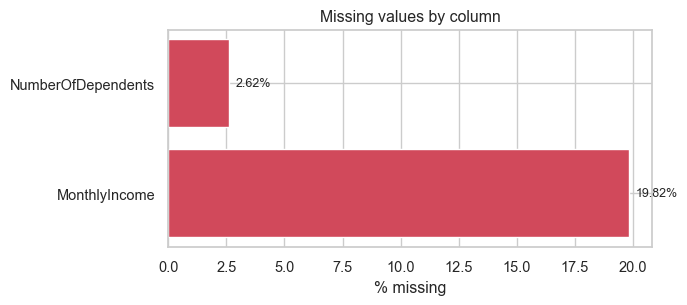

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.2))
if len(na_table):
    ax.barh(na_table.index, na_table["missing_%"], color=PALETTE[1])
    for i, v in enumerate(na_table["missing_%"]):
        ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
    ax.set_xlabel("% missing")
    ax.set_title("Missing values by column")
else:
    ax.text(0.5, 0.5, "No missing values", ha="center")
plt.tight_layout()
plt.show()


**Finding:** two columns have missing data — `MonthlyIncome` (~19.8%) and
`NumberOfDependents` (~2.6%). Both are plausible "not reported" fields rather
than random glitches; we test whether they're missing-at-random in Section 8.

### 2.2 Duplicates

In [19]:
exact_dupes = df.duplicated().sum()
dupes_ignoring_id = df.drop(columns=["ID"]).duplicated().sum()
print(f"Fully identical rows (incl. ID): {exact_dupes}")
print(f"Identical on every column EXCEPT the ID index: {dupes_ignoring_id}")


Fully identical rows (incl. ID): 0
Identical on every column EXCEPT the ID index: 609


**Finding:** there are no duplicate `ID`s (it's just a row index), but
**609 rows are duplicated on every real feature** once `ID` is excluded.
These are worth flagging for modeling (they can leak between train/test splits)
even though we won't drop them in this EDA pass.

### 2.3 Impossible / sentinel values

In [20]:
print("age == 0 rows:", (df["age"] == 0).sum())
print("age range:", df["age"].min(), "-", df["age"].max())
df[df["age"] == 0]


age == 0 rows: 1
age range: 0 - 109


,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0000,0,1,0.4369,"6,000.0000",6,0,2,0,2.0000


In [21]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

sentinel_mask = (df[late_cols] >= 96).any(axis=1)
print(f"Rows containing a 96/98 sentinel code in any 'DaysPastDue' column: {sentinel_mask.sum()}")

for c in late_cols:
    vc = df[c].value_counts().sort_index(ascending=False).head(6)
    print(f"\nTop values in {c}:")
    print(vc)


Rows containing a 96/98 sentinel code in any 'DaysPastDue' column: 269

Top values in NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
10      4
Name: count, dtype: int64

Top values in NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
7       9
Name: count, dtype: int64

Top values in NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
13      4
Name: count, dtype: int64


In [22]:
print("Default rate for sentinel rows (>=96):", df.loc[sentinel_mask, "SeriousDlqin2yrs"].mean().round(4))
print("Default rate overall                    :", df["SeriousDlqin2yrs"].mean().round(4))
print("MonthlyIncome missing rate in sentinel rows:", df.loc[sentinel_mask, "MonthlyIncome"].isnull().mean().round(4))


Default rate for sentinel rows (>=96): 0.5465
Default rate overall                    : 0.0668
MonthlyIncome missing rate in sentinel rows: 0.4498


**Finding — important data quality issue:** 269 rows (≈0.18%) carry the values
**96 or 98** in all three "days past due" columns simultaneously. These are not
real counts of 96–98 late payments; they look like **coded/sentinel values**
(a common artifact of this specific Kaggle dataset). This small subgroup has a
**default rate of ~55% vs. ~6.7% overall** — an 8x lift — and much higher
missingness in `MonthlyIncome`. This group should be handled explicitly
(flag as a separate category or cap/clip) rather than treated as ordinary
large counts, or it will distort any distance/linear-based model.

In [23]:
print("RevolvingUtilizationOfUnsecuredLines > 1  :", (df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum())
print("RevolvingUtilizationOfUnsecuredLines > 10 :", (df["RevolvingUtilizationOfUnsecuredLines"] > 10).sum())
print("max value                                  :", df["RevolvingUtilizationOfUnsecuredLines"].max())
print()
print("DebtRatio > 1  :", (df["DebtRatio"] > 1).sum())
print("DebtRatio > 10 :", (df["DebtRatio"] > 10).sum())
print("max value      :", df["DebtRatio"].max())


RevolvingUtilizationOfUnsecuredLines > 1  : 3321
RevolvingUtilizationOfUnsecuredLines > 10 : 241
max value                                  : 50708.0

DebtRatio > 1  : 35137
DebtRatio > 10 : 28877
max value      : 329664.0


**Finding:** `RevolvingUtilizationOfUnsecuredLines` is conceptually a ratio
that should sit in **[0, 1]**, yet it reaches **50,708** and 3,321 rows exceed 1.
`DebtRatio` shows the same pattern (max ≈ 329,664; 35,137 rows > 1). These are
almost certainly data-entry errors or unit mismatches, not genuine values, and
they will dominate any mean/std-based scaling unless winsorized, log-transformed,
or capped.

## 3. Target variable — class balance

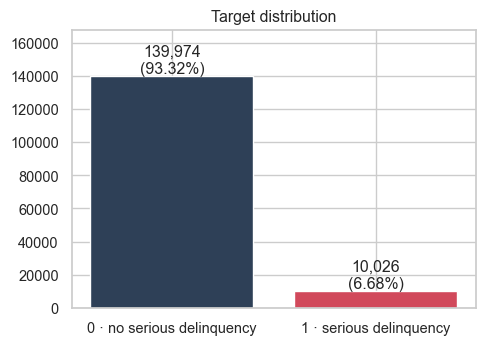

Positive (default) rate: 6.68%
Imbalance ratio: 14.0 : 1


In [24]:
target = "SeriousDlqin2yrs"
vc = df[target].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3.6))
bars = ax.bar(["0 · no serious delinquency", "1 · serious delinquency"], vc.values,
              color=[PALETTE[0], PALETTE[1]])
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(df):.2%})",
            ha="center", va="bottom")
ax.set_ylim(0, vc.max()*1.2)
ax.set_title("Target distribution")
plt.tight_layout()
plt.show()

print(f"Positive (default) rate: {df[target].mean():.2%}")
print(f"Imbalance ratio: {(1-df[target].mean())/df[target].mean():.1f} : 1")


**Finding:** the dataset is **strongly imbalanced** — only **6.68%** of
borrowers defaulted. Accuracy alone will be a misleading metric; ROC-AUC /
PR-AUC, class weighting, or resampling should be used downstream.

## 4. Univariate analysis

Distribution of every feature, using a log-scale where the raw scale is too
skewed to read (utilization, debt ratio, income).

In [25]:
feature_cols = [c for c in df.columns if c not in ["ID", target]]
df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,"150,000.0000",6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,"50,708.0000"
age,"150,000.0000",52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,"150,000.0000",0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,"150,000.0000",353.0051,"2,037.8185",0.0000,0.1751,0.3665,0.8683,"329,664.0000"
MonthlyIncome,"120,269.0000","6,670.2212","14,384.6742",0.0000,"3,400.0000","5,400.0000","8,249.0000","3,008,750.0000"
NumberOfOpenCreditLinesAndLoans,"150,000.0000",8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,"150,000.0000",0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,"150,000.0000",1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,"150,000.0000",0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000
NumberOfDependents,"146,076.0000",0.7572,1.1151,0.0000,0.0000,0.0000,1.0000,20.0000


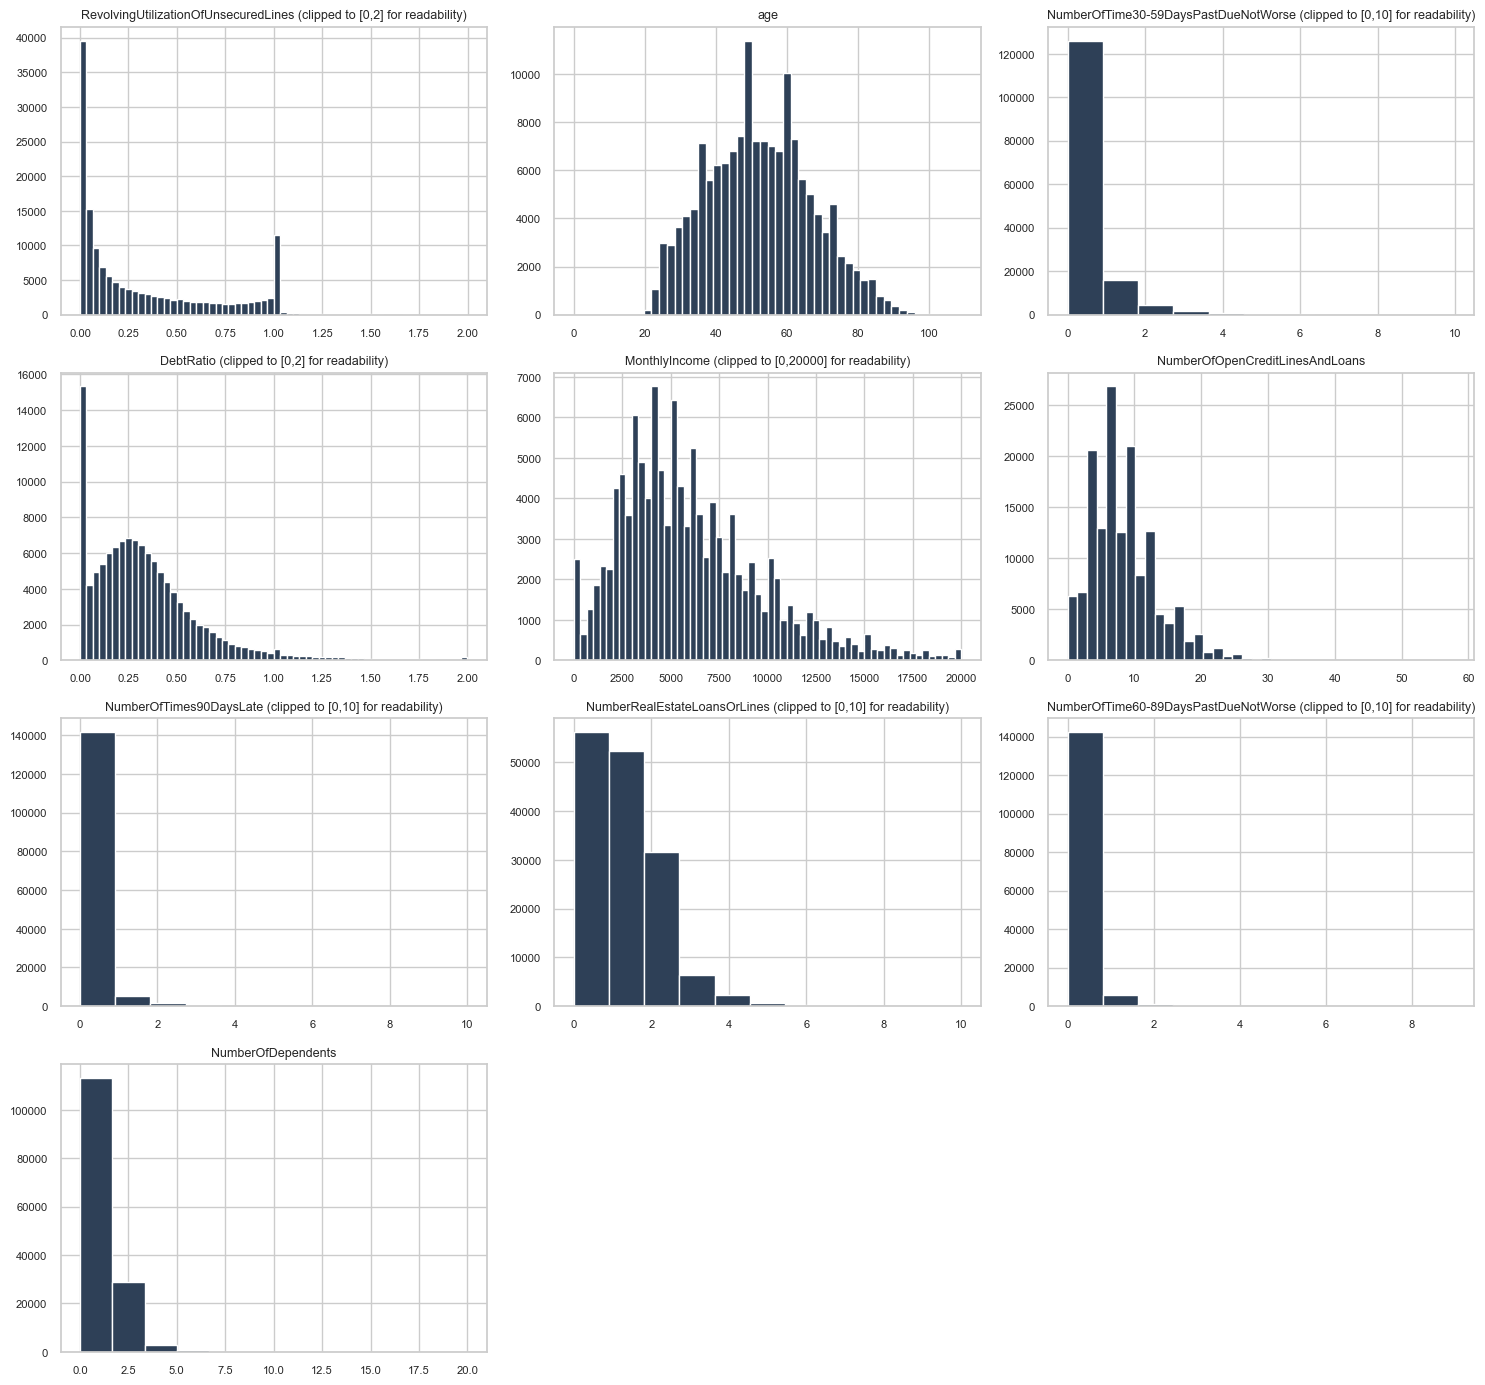

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.ravel()

plot_specs = {
    "RevolvingUtilizationOfUnsecuredLines": dict(clip=(0, 2), bins=60),
    "age": dict(clip=None, bins=50),
    "NumberOfTime30-59DaysPastDueNotWorse": dict(clip=(0, 10), bins=11),
    "DebtRatio": dict(clip=(0, 2), bins=60),
    "MonthlyIncome": dict(clip=(0, 20000), bins=60),
    "NumberOfOpenCreditLinesAndLoans": dict(clip=None, bins=40),
    "NumberOfTimes90DaysLate": dict(clip=(0, 10), bins=11),
    "NumberRealEstateLoansOrLines": dict(clip=(0, 10), bins=11),
    "NumberOfTime60-89DaysPastDueNotWorse": dict(clip=(0, 10), bins=11),
    "NumberOfDependents": dict(clip=None, bins=12),
}

for ax, col in zip(axes, feature_cols):
    spec = plot_specs.get(col, dict(clip=None, bins=40))
    data = df[col].dropna()
    if spec["clip"] is not None:
        lo, hi = spec["clip"]
        data = data[(data >= lo) & (data <= hi)]
        suffix = f" (clipped to [{lo},{hi}] for readability)"
    else:
        suffix = ""
    ax.hist(data, bins=spec["bins"], color=PALETTE[0], edgecolor="white")
    ax.set_title(col + suffix, fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Findings:**
- `age` is roughly bell-shaped, centered in the 40s-50s, with one impossible `age=0` row.
- `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` are extremely right-skewed with a long tail of implausible outliers (see §2.3).
- The three "days past due" counters are heavily zero-inflated (most borrowers have 0 late payments) with a small sentinel spike at 96/98.
- `MonthlyIncome` is right-skewed, typical of income data — a log transform will help most models.
- `NumberOfDependents` and `NumberRealEstateLoansOrLines` are low-count discrete variables, also zero-inflated.

## 5. Outlier detection (boxplots + IQR rule)

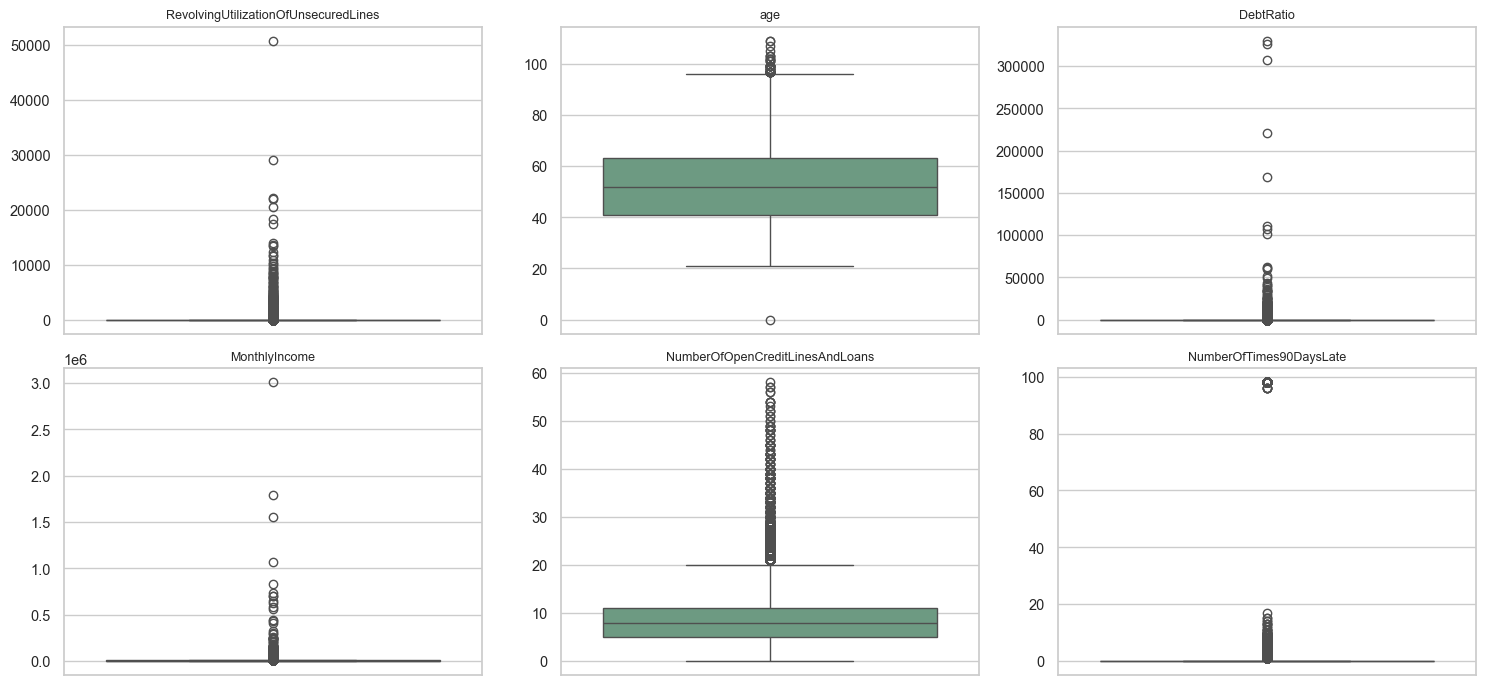

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
box_cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
            "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate"]

for ax, col in zip(axes, box_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color=PALETTE[2])
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [28]:
def iqr_outlier_report(series, name):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lo) | (s > hi)).sum()
    return {"feature": name, "q1": q1, "q3": q3, "IQR_low": lo, "IQR_high": hi,
            "n_outliers": n_out, "pct_outliers": round(n_out/len(s)*100, 2)}

report = pd.DataFrame([iqr_outlier_report(df[c], c) for c in feature_cols]).set_index("feature")
report.sort_values("pct_outliers", ascending=False)


,q1,q3,IQR_low,IQR_high,n_outliers,pct_outliers
feature,,,,,,
DebtRatio,0.1751,0.8683,-0.8647,1.9080,31311,20.8700
NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,23982,15.9900
NumberOfDependents,0.0000,1.0000,-1.5000,2.5000,13336,9.1300
NumberOfTimes90DaysLate,0.0000,0.0000,0.0000,0.0000,8338,5.5600
NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,7604,5.0700
MonthlyIncome,"3,400.0000","8,249.0000","-3,873.5000","15,522.5000",4879,4.0600
NumberOfOpenCreditLinesAndLoans,5.0000,11.0000,-4.0000,20.0000,3980,2.6500
NumberRealEstateLoansOrLines,0.0000,2.0000,-3.0000,5.0000,793,0.5300
RevolvingUtilizationOfUnsecuredLines,0.0299,0.5590,-0.7639,1.3528,763,0.5100


**Finding:** by the standard 1.5×IQR rule, `RevolvingUtilizationOfUnsecuredLines`,
`DebtRatio`, and the past-due counters show the highest outlier rates — consistent
with the sentinel-code and unit-error issues already identified above rather than
genuine extreme-but-valid customers.

## 6. Bivariate analysis — features vs. target

For each feature we compare the distribution/mean between defaulters (1) and
non-defaulters (0), and show the default rate across bins.

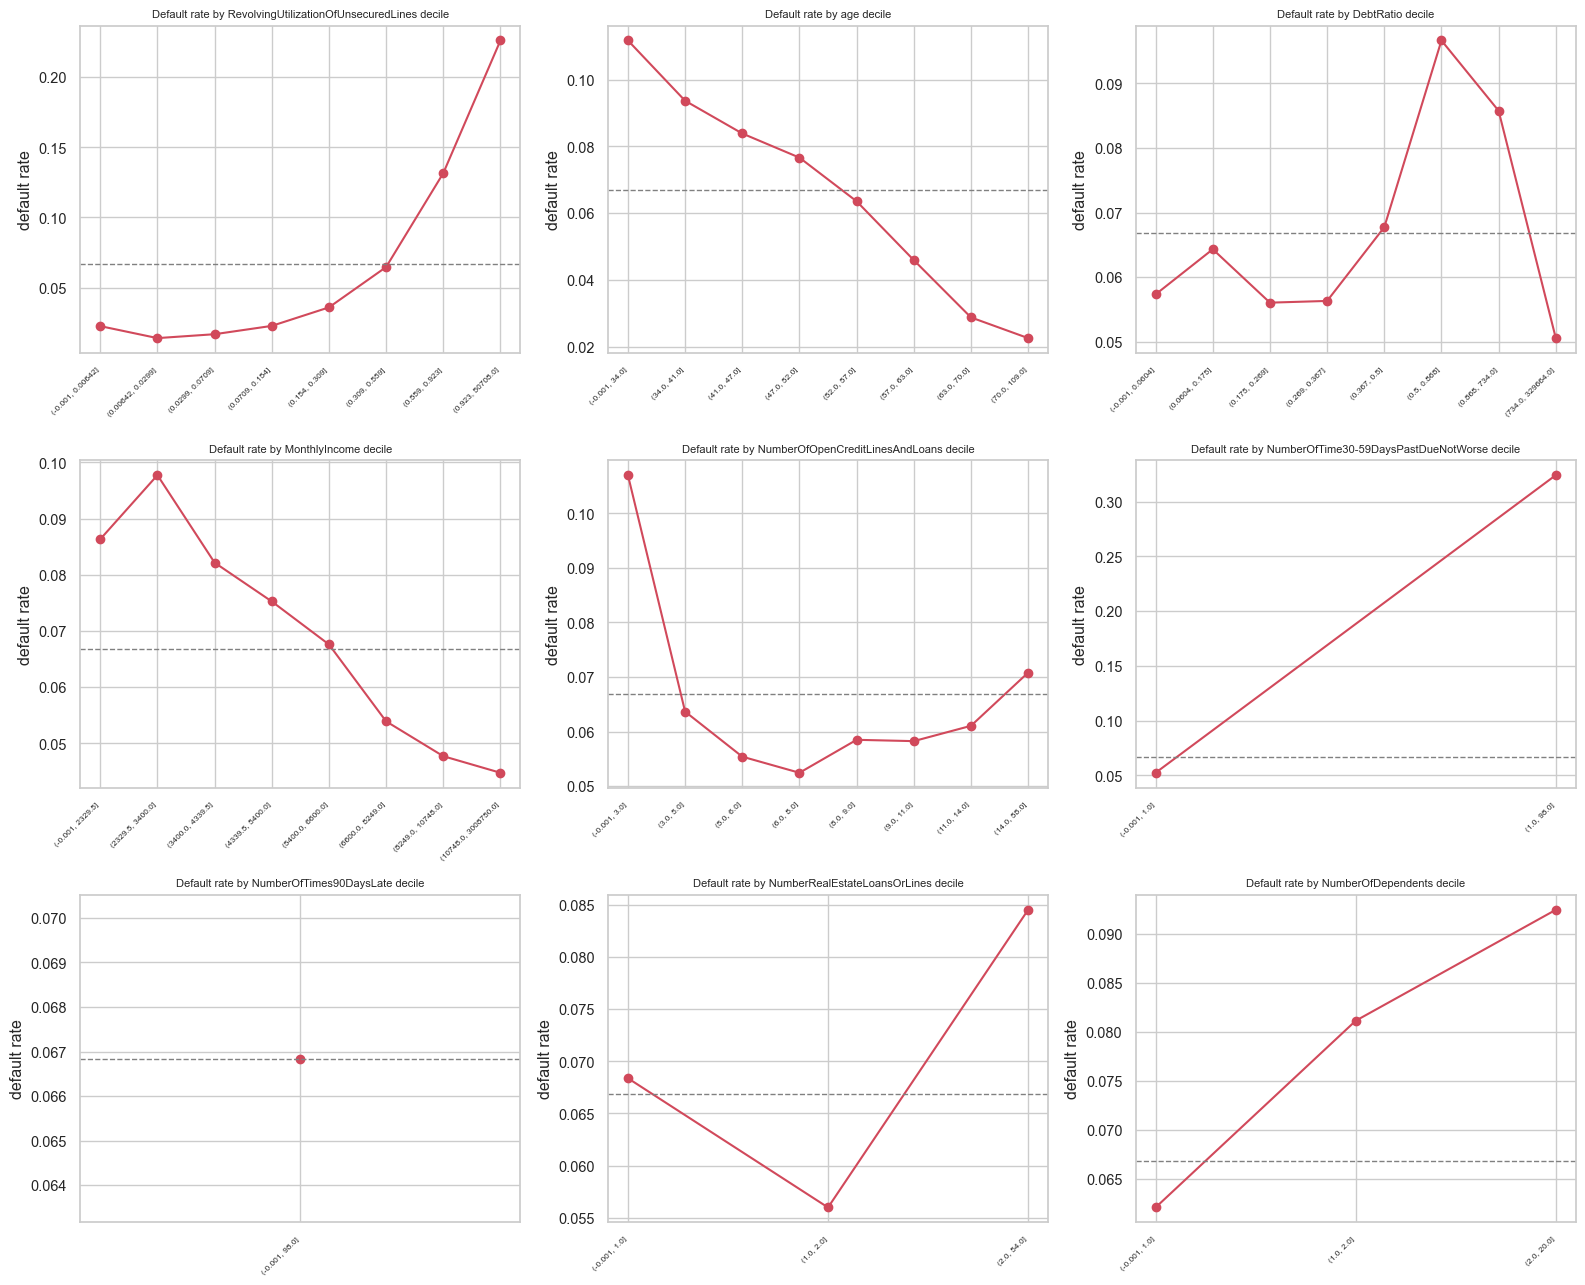

In [29]:
def default_rate_by_bin(data, col, target, bins=10, clip=None):
    d = data[[col, target]].dropna().copy()
    if clip is not None:
        d = d[(d[col] >= clip[0]) & (d[col] <= clip[1])]
    d["bin"] = pd.qcut(d[col], q=bins, duplicates="drop")
    out = d.groupby("bin", observed=True)[target].agg(["mean", "count"])
    out.columns = ["default_rate", "n"]
    return out

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.ravel()

bivar_cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
              "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans",
              "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
              "NumberRealEstateLoansOrLines", "NumberOfDependents"]

for ax, col in zip(axes, bivar_cols):
    try:
        tab = default_rate_by_bin(df, col, target, bins=8)
        ax.plot(range(len(tab)), tab["default_rate"], marker="o", color=PALETTE[1])
        ax.set_xticks(range(len(tab)))
        ax.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right", fontsize=6)
    except Exception as e:
        ax.text(0.5, 0.5, f"n/a: {e}", ha="center", fontsize=7)
    ax.axhline(df[target].mean(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"Default rate by {col} decile", fontsize=8)
    ax.set_ylabel("default rate")

plt.tight_layout()
plt.show()


**Findings (dashed line = overall base rate of 6.68%):**
- Default rate **rises sharply with age going down** — younger borrowers default noticeably more; it falls steadily into older age brackets.
- Default rate **increases monotonically** with the past-due counters and with `RevolvingUtilizationOfUnsecuredLines` — both behave exactly as expected of strong risk signals.
- `MonthlyIncome` shows a mild inverse relationship — lower income bands skew toward higher default.
- `NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines` show a much flatter/non-monotonic relationship — weaker standalone signal, may still interact with other features.

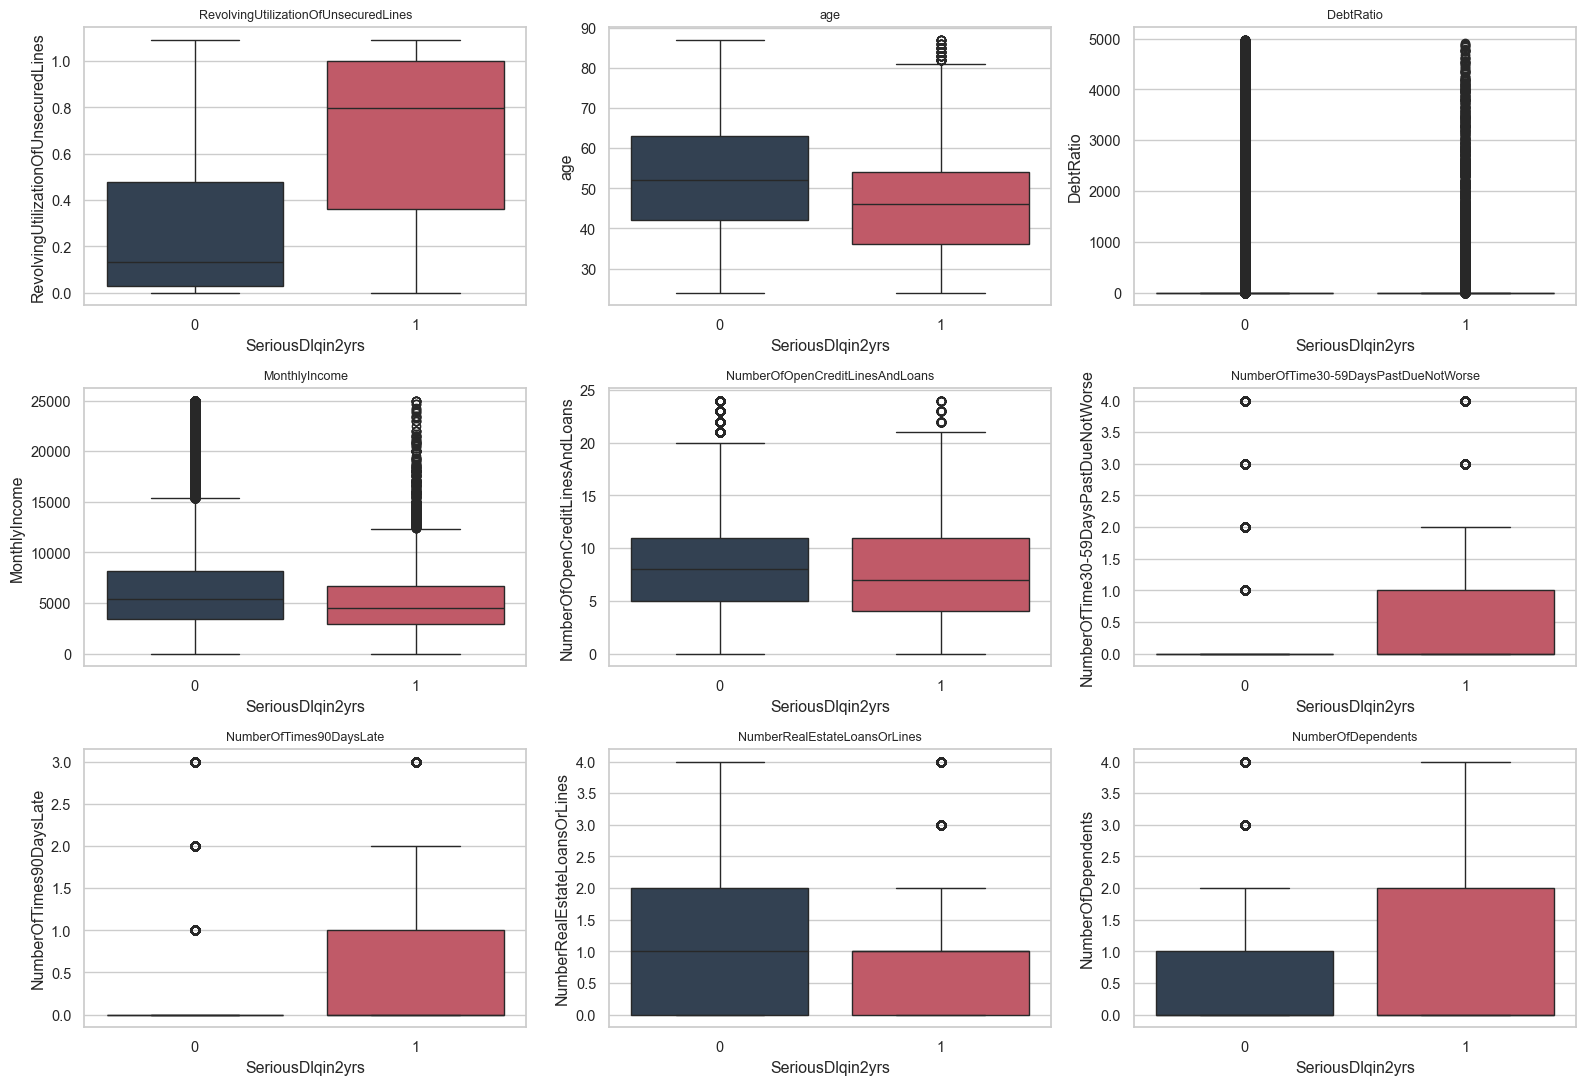

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.ravel()

for ax, col in zip(axes, bivar_cols):
    d = df[[col, target]].dropna()
    lo, hi = d[col].quantile([0.01, 0.99])
    d = d[(d[col] >= lo) & (d[col] <= hi)]
    sns.boxplot(data=d, x=target, y=col, ax=ax, palette=[PALETTE[0], PALETTE[1]])
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("SeriousDlqin2yrs")

plt.tight_layout()
plt.show()


## 7. Correlation & multivariate structure

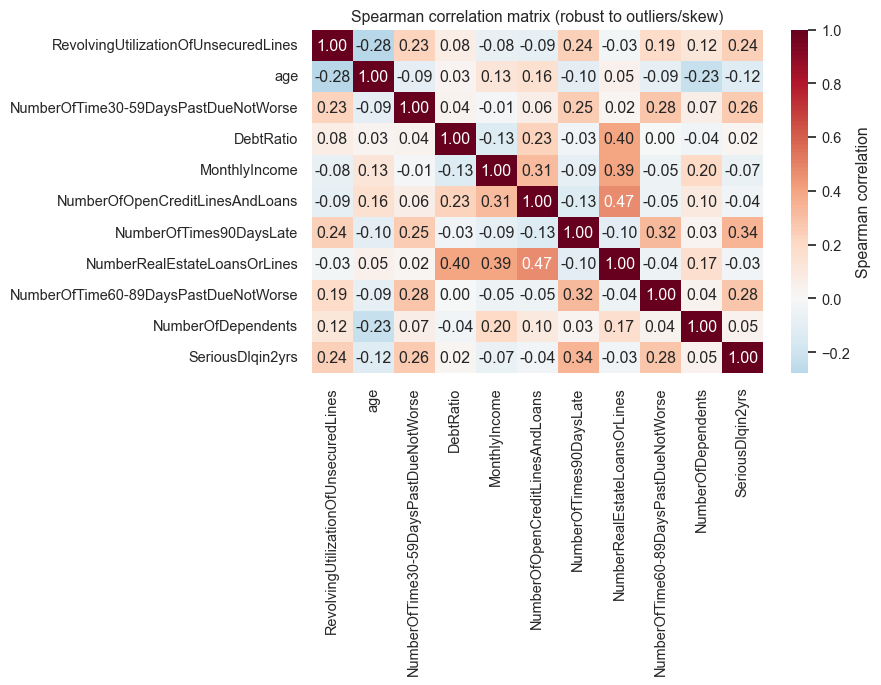

In [31]:
corr = df[feature_cols + [target]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman correlation matrix (robust to outliers/skew)")
plt.tight_layout()
plt.show()


In [32]:
corr_with_target = corr[target].drop(target).sort_values(key=abs, ascending=False)
corr_with_target.to_frame("spearman_corr_with_target")


,spearman_corr_with_target
NumberOfTimes90DaysLate,0.3423
NumberOfTime60-89DaysPastDueNotWorse,0.2771
NumberOfTime30-59DaysPastDueNotWorse,0.2574
RevolvingUtilizationOfUnsecuredLines,0.2404
age,-0.1170
MonthlyIncome,-0.0670
NumberOfDependents,0.0460
NumberOfOpenCreditLinesAndLoans,-0.0386
NumberRealEstateLoansOrLines,-0.0341
DebtRatio,0.0206


**Findings:**
- The three "days past due" counters are **highly correlated with each other**
  (they measure the same underlying behavior at different severities) and are
  the strongest correlates of the target — expected, since they are the most
  direct historical proxies for delinquency.
- `RevolvingUtilizationOfUnsecuredLines` is the single strongest standalone
  correlate with the target.
- `age` correlates negatively with the target (older ⇒ lower risk), and mildly
  negatively with the past-due counters too.
- `DebtRatio`, `MonthlyIncome`, `NumberOfOpenCreditLinesAndLoans`, and
  `NumberRealEstateLoansOrLines` show comparatively weak linear/rank correlation
  with the target on their own — they will likely help mainly through interactions
  or non-linear models rather than as strong solo predictors.

## 8. Missingness patterns — is data missing at random?

We test whether `MonthlyIncome` and `NumberOfDependents` are missing completely
at random, or whether missingness itself correlates with default risk (MNAR/MAR),
which matters for the correct imputation strategy.

In [33]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isnull().astype(int)

for flag in ["MonthlyIncome_missing", "NumberOfDependents_missing"]:
    rate_missing = df.loc[df[flag] == 1, target].mean()
    rate_present = df.loc[df[flag] == 0, target].mean()
    print(f"{flag}: default rate when MISSING = {rate_missing:.2%}, "
          f"when PRESENT = {rate_present:.2%}")


MonthlyIncome_missing: default rate when MISSING = 5.61%, when PRESENT = 6.95%
NumberOfDependents_missing: default rate when MISSING = 4.56%, when PRESENT = 6.74%


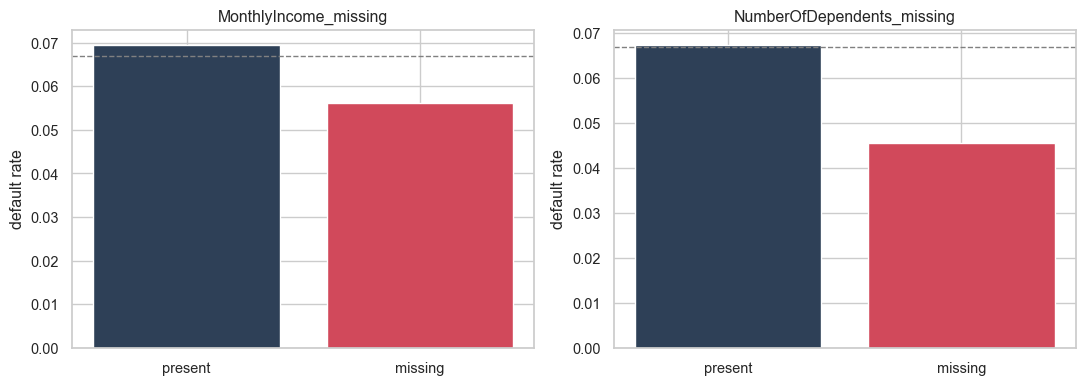

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, flag in zip(axes, ["MonthlyIncome_missing", "NumberOfDependents_missing"]):
    rates = df.groupby(flag)[target].mean()
    ax.bar(["present", "missing"], rates.values, color=[PALETTE[0], PALETTE[1]])
    ax.axhline(df[target].mean(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(flag)
    ax.set_ylabel("default rate")
plt.tight_layout()
plt.show()


**Finding:** default rate is **meaningfully higher when `MonthlyIncome` is
missing** than when it's reported — this points to **MAR/MNAR rather than
MCAR**, i.e. missingness itself carries signal. A missing-value indicator
feature (kept alongside imputed values) is recommended rather than silent
mean/median imputation.

## 9. Summary of key findings & recommendations

**Data quality issues found**
1. One row has `age = 0` (impossible) — should be treated as missing/dropped.
2. 269 rows carry sentinel codes **96/98** across all three "days past due"
   columns — a distinct high-risk subgroup (≈55% default rate) that should be
   flagged rather than treated as literal counts.
3. `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` contain extreme,
   almost certainly erroneous outliers (max values in the tens of thousands
   for what should be bounded ratios) — cap/winsorize or log-transform.
4. 609 rows are exact duplicates on every real feature (different `ID` only) —
   worth deduplicating before train/test splitting to avoid leakage.
5. `MonthlyIncome` (~19.8%) and `NumberOfDependents` (~2.6%) have missing
   values, and missingness is **not random** — it correlates with higher
   default risk, so an explicit "is-missing" indicator should be kept.

**Target & modeling implications**
- Severe class imbalance (6.68% positive) → use ROC-AUC/PR-AUC, class weights,
  or resampling; avoid plain accuracy.
- Strongest predictors: the past-due counters and revolving utilization;
  age is protective; income, debt ratio, and credit-line counts are weaker
  standalone signals but may add value through interactions or tree-based
  models that handle non-linearities and outliers more gracefully than
  linear models.
- Recommended preprocessing before modeling: cap/winsorize utilization and
  debt ratio, isolate or flag the 96/98 sentinel rows, impute income/dependents
  with a missing-indicator retained, and consider log-transforming income.


## Part 3 -- Feature Engineering

`build_gmsc_features` is self-contained: it reads `GMSC_PATH` and performs its own cleaning steps (income-missing flag, debt-ratio fix, 96/98 placeholder fix, age fix, duplicate flag, dependents fill) that mirror Part 2 but follow the FE spec's exact rules, plus every derived feature required for modeling. This is independent of the manually-cleaned `df` from Part 2 (which stays available above for inspection).

In [35]:
def build_gmsc_features(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # -- duplicate review: flag rows identical except the row-id column ----
    id_like_cols = [c for c in df.columns if c.startswith("Unnamed")]
    dup_check_cols = [c for c in df.columns if c not in id_like_cols]
    duplicate_flag = df.duplicated(subset=dup_check_cols, keep=False).astype(int)
    df = df.drop(columns=id_like_cols)

    out = pd.DataFrame(index=df.index)
    out["duplicate_flag"] = duplicate_flag.values

    # -- income_missing_flag (before any use of income) --------------------
    out["income_missing_flag"] = df["MonthlyIncome"].isna().astype(int)

    # income: REAL
    out["income"] = df["MonthlyIncome"]

    # -- debt_ratio fix: NaN when income missing/0; flag outlier > 5 -------
    valid_income_mask = out["income"].notna() & (out["income"] > 0)
    debt_ratio_clean = df["DebtRatio"].where(valid_income_mask)
    out["derived_debt_ratio_outlier"] = (df["DebtRatio"] > 5).astype(int)

    # -- placeholder code fix: 96/98 in past-due cols -> NaN + flag --------
    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]
    placeholder_mask = pd.Series(False, index=df.index)
    past_due_clean = pd.DataFrame(index=df.index)
    for col in past_due_cols:
        is_placeholder = df[col].isin([96, 98])
        placeholder_mask = placeholder_mask | is_placeholder
        past_due_clean[col] = df[col].where(~is_placeholder)
    out["derived_placeholder_code_flag"] = placeholder_mask.astype(int)

    # -- age fix: 0 -> NaN ---------------------------------------------------
    out["age"] = df["age"].replace(0, np.nan)

    # -- dependents_missing_flag + fill(0) ----------------------------------
    out["dependents_missing_flag"] = df["NumberOfDependents"].isna().astype(int)
    out["dependents"] = df["NumberOfDependents"].fillna(0)

    # -- derived_late_count / derived_late_severity (post placeholder-fix) --
    out["derived_late_count"] = past_due_clean.sum(axis=1, skipna=True)
    out["derived_late_severity"] = (
        past_due_clean["NumberOfTime30-59DaysPastDueNotWorse"].fillna(0) * 1
        + past_due_clean["NumberOfTime60-89DaysPastDueNotWorse"].fillna(0) * 2
        + past_due_clean["NumberOfTimes90DaysLate"].fillna(0) * 3
    )
    # late_payments: harmonized column = the cleaned late count
    out["late_payments"] = out["derived_late_count"]

    # -- derived_obligations: debt_ratio * income, only when income>0 AND
    # debt_ratio<=5 (per FE.pdf rule) --------------------------------------
    obligations_mask = valid_income_mask & (df["DebtRatio"] <= 5)
    out["derived_obligations"] = np.where(
        obligations_mask, df["DebtRatio"] * out["income"], np.nan
    )
    # monthly_debt_payment: PROXY = derived_obligations (harmonized name)
    out["monthly_debt_payment"] = out["derived_obligations"]
    out["monthly_debt_payment_is_proxy"] = 1

    # derived_expense_ratio = cleaned debt ratio
    out["derived_expense_ratio"] = debt_ratio_clean

    # derived_monthly_surplus = income - obligations
    out["derived_monthly_surplus"] = out["income"] - out["derived_obligations"]
    out["savings"] = out["derived_monthly_surplus"]
    out["savings_is_proxy"] = 1

    # derived_overspend_flag = debt_ratio > 1 (cleaned)
    out["derived_overspend_flag"] = (debt_ratio_clean > 1).astype(int)

    # derived_utilization_capped = min(utilization, 1) + outlier flag
    util = df["RevolvingUtilizationOfUnsecuredLines"]
    out["derived_utilization_capped"] = util.clip(upper=1)
    out["derived_utilization_outlier_flag"] = (util > 1).astype(int)
    out["revolving_utilization_ref"] = util

    # derived_log_income = log1p(income)
    out["derived_log_income"] = np.log1p(out["income"].clip(lower=0))

    # debt: MISSING (no outstanding-balance dollar figure exists in GMSC)
    out["debt"] = np.nan

    # expenses: MISSING (no separate living-expense figure in GMSC)
    out["expenses"] = np.nan

    # rent: MISSING
    out["rent"] = np.nan

    # income_stability: MISSING (single snapshot, no history)
    out["income_stability"] = np.nan

    # month: MISSING (no time dimension in GMSC)
    out["month"] = np.nan

    out["target"] = df["SeriousDlqin2yrs"]
    out["source_dataset"] = "gmsc"
    return out


In [36]:
gmsc = build_gmsc_features(GMSC_PATH)
print("GMSC feature shape:", gmsc.shape)
gmsc.head()


GMSC feature shape: (150000, 30)


,duplicate_flag,income_missing_flag,income,derived_debt_ratio_outlier,derived_placeholder_code_flag,age,dependents_missing_flag,dependents,derived_late_count,derived_late_severity,late_payments,derived_obligations,monthly_debt_payment,monthly_debt_payment_is_proxy,derived_expense_ratio,derived_monthly_surplus,savings,savings_is_proxy,derived_overspend_flag,derived_utilization_capped,derived_utilization_outlier_flag,revolving_utilization_ref,derived_log_income,debt,expenses,rent,income_stability,month,target,source_dataset
0,0,0,"9,120.0000",0,0,45.0000,0,2.0000,2.0000,2.0000,2.0000,"7,323.1970","7,323.1970",1,0.8030,"1,796.8030","1,796.8030",1,0,0.7661,0,0.7661,9.1183,NaN,NaN,NaN,NaN,NaN,1,gmsc
1,0,0,"2,600.0000",0,0,40.0000,0,1.0000,0.0000,0.0000,0.0000,316.8781,316.8781,1,0.1219,"2,283.1219","2,283.1219",1,0,0.9572,0,0.9572,7.8637,NaN,NaN,NaN,NaN,NaN,0,gmsc
2,0,0,"3,042.0000",0,0,38.0000,0,0.0000,2.0000,4.0000,2.0000,258.9149,258.9149,1,0.0851,"2,783.0851","2,783.0851",1,0,0.6582,0,0.6582,8.0206,NaN,NaN,NaN,NaN,NaN,0,gmsc
3,0,0,"3,300.0000",0,0,30.0000,0,0.0000,0.0000,0.0000,0.0000,118.9640,118.9640,1,0.0360,"3,181.0360","3,181.0360",1,0,0.2338,0,0.2338,8.1020,NaN,NaN,NaN,NaN,NaN,0,gmsc
4,0,0,"63,588.0000",0,0,49.0000,0,0.0000,1.0000,1.0000,1.0000,"1,584.9751","1,584.9751",1,0.0249,"62,003.0249","62,003.0249",1,0,0.9072,0,0.9072,11.0602,NaN,NaN,NaN,NaN,NaN,0,gmsc


## Part 4 -- Train / test split

In [37]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

# GMSC: one row per client -> plain stratified split on the target
gmsc_train, gmsc_test = train_test_split(
    gmsc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=gmsc["target"],
)

print("GMSC train:", gmsc_train.shape, " test:", gmsc_test.shape)
print("GMSC train target rate:", round(gmsc_train["target"].mean(), 4),
      "| test target rate:", round(gmsc_test["target"].mean(), 4))


GMSC train: (120000, 30)  test: (30000, 30)
GMSC train target rate: 0.0668 | test target rate: 0.0668


## Part 5 -- Save + download

In [38]:
gmsc.to_csv("gmsc_target_features.csv", index=False)
gmsc_train.to_csv("gmsc_train.csv", index=False)
gmsc_test.to_csv("gmsc_test.csv", index=False)

_OUT_FILES = ["gmsc_target_features.csv", "gmsc_train.csv", "gmsc_test.csv"]

try:
    from google.colab import files as _files
    for _f in _OUT_FILES:
        _files.download(_f)
except ImportError:
    print("Saved locally:", ", ".join(_OUT_FILES))


Saved locally: gmsc_target_features.csv, gmsc_train.csv, gmsc_test.csv


## Part 6 -- Preprocessing Pipeline + Baseline (Logistic Regression)  

In [39]:
# 1. Define Target and Feature Groups
TARGET = "target"

CONT_COLS = [
    "age",
    "derived_log_income",
    "derived_obligations",
    "derived_monthly_surplus",
    "derived_expense_ratio",
    "derived_utilization_capped",
]

COUNT_COLS = [
    "dependents",
    "derived_late_count",
    "derived_late_severity",
]

FLAG_COLS = [
    "income_missing_flag",
    "dependents_missing_flag",
    "derived_placeholder_code_flag",
    "derived_debt_ratio_outlier",
    "derived_overspend_flag",
    "derived_utilization_outlier_flag",
]

NUMERIC_COLS = CONT_COLS + COUNT_COLS
FEATURE_COLS = NUMERIC_COLS + FLAG_COLS

# 2. Extract Training Features and Target
X_train = gmsc_train[FEATURE_COLS].copy()
y_train = gmsc_train[TARGET].astype(int).copy()

# 3. Simple Outlier Capping (1st and 99th percentiles)
lower_limits = X_train[NUMERIC_COLS].quantile(0.01)
upper_limits = X_train[NUMERIC_COLS].quantile(0.99)
X_train[NUMERIC_COLS] = X_train[NUMERIC_COLS].clip(lower=lower_limits, upper=upper_limits, axis=1)

print("Features selected and outliers clipped successfully.")

Features selected and outliers clipped successfully.


### 2. Preprocessing & Baseline Pipeline
Construct a `ColumnTransformer` to impute missing values using median statistics and scale numeric features, while passing binary flags unchanged. Combine preprocessing with a class-balanced `LogisticRegression` baseline.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Numerical Pipeline: Median Imputation + Standard Scaling
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combine Preprocessing: Transform numerical features and pass flags unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUMERIC_COLS),
        ("flags", "passthrough", FLAG_COLS)
    ]
)

# Full Baseline Pipeline with Class Balancing
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

### 3. Cross-Validation Evaluation
Evaluate the baseline using 5-fold Stratified Cross-Validation. Given the severe class imbalance, focus primarily on PR-AUC (Average Precision) alongside ROC-AUC.

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 5-Fold Stratified Split to preserve class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Baseline using PR-AUC (Average Precision) and ROC-AUC
cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc"},
    n_jobs=-1
)

# Display Cross-Validation Performance
print("=== Cross-Validation Results ===")
print("PR-AUC  :", round(cv_results["test_pr_auc"].mean(), 4))
print("ROC-AUC :", round(cv_results["test_roc_auc"].mean(), 4))

=== Cross-Validation Results ===
PR-AUC  : 0.3888
ROC-AUC : 0.8561


### 4. Final Fit and Feature Interpretability
Fit the pipeline on the full training dataset and extract model coefficients to evaluate feature directionality and impact on default probability.

In [42]:
import pandas as pd

# 1. Fit full baseline on the complete training set
baseline_model.fit(X_train, y_train)

# 2. Extract feature names and model coefficients
feature_names = baseline_model.named_steps["preprocess"].get_feature_names_out()
coefficients = baseline_model.named_steps["clf"].coef_[0]

# 3. Format and sort by impact on default risk
coef_summary = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
}).sort_values(by="Coefficient", ascending=False)

display(coef_summary)

,Feature,Coefficient
11,flags__derived_placeholder_code_flag,2.5729
5,num__derived_utilization_capped,0.6398
8,num__derived_late_severity,0.4476
13,flags__derived_overspend_flag,0.3760
14,flags__derived_utilization_outlier_flag,0.3592
7,num__derived_late_count,0.3403
2,num__derived_obligations,0.1867
12,flags__derived_debt_ratio_outlier,0.1588
1,num__derived_log_income,0.0664
6,num__dependents,0.0208


### 5. Export Pipeline Artifacts
Save the fitted preprocessor, full baseline model, and column schema for downstream modeling and production serving.

In [43]:
import joblib

# Fit baseline on all training data
baseline_model.fit(X_train, y_train)

# Save preprocessor and complete baseline model for the team
joblib.dump(baseline_model.named_steps["preprocess"], "gmsc_preprocessor.joblib")
joblib.dump(baseline_model, "gmsc_baseline_model.joblib")

print("Pipeline artifacts saved successfully.")

Pipeline artifacts saved successfully.


## Part 7 -- XGBOOST MODEL + hyperparameter tuning

In [44]:
import numpy as np
import xgboost as xgb

# 1. Transform training features using our fitted preprocessor
X_train_transformed = baseline_model.named_steps["preprocess"].transform(X_train)

# 2. Calculate scale_pos_weight to handle class imbalance (Negatives / Positives)
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
scale_pos_weight = num_negatives / num_positives

print(f"Negative samples: {num_negatives} | Positive samples: {num_positives}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Negative samples: 111979 | Positive samples: 8021
Calculated scale_pos_weight: 13.96


In [45]:
!pip install optuna

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.4 MB 3.6 MB/s eta 0:00:01
   --------------------- ------------------ 1.3/2.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 2.1/2.4 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 2.4/2.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 2.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import optuna
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

# Make Optuna output cleaner and less verbose
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Search space for key XGBoost hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "eval_metric": "logloss",
        "n_jobs": -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_scores = []

    for train_idx, val_idx in cv.split(X_train_transformed, y_train):
        X_tr, X_val = X_train_transformed[train_idx], X_train_transformed[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr, verbose=False)

        preds_prob = clf.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, preds_prob)
        pr_scores.append(score)

    return np.mean(pr_scores)

# Run Optuna study (20 trials is fast and effective)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(f"Best Trial PR-AUC: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best Trial PR-AUC: 0.3961
Best Hyperparameters:
  n_estimators: 200
  max_depth: 4
  learning_rate: 0.06516233595021982
  subsample: 0.9609328689417147
  colsample_bytree: 0.7099057418462011
  min_child_weight: 5


In [47]:
from sklearn.model_selection import cross_validate

# Build best model using optimal parameters from Optuna
best_params = study.best_params
best_params["scale_pos_weight"] = scale_pos_weight
best_params["random_state"] = 42
best_params["eval_metric"] = "logloss"
best_params["n_jobs"] = -1

best_xgb = xgb.XGBClassifier(**best_params)

# 5-Fold Stratified Cross-Validation on the full training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_results = cross_validate(
    best_xgb,
    X_train_transformed,
    y_train,
    cv=cv,
    scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc"},
    n_jobs=-1
)

xgb_pr_mean = xgb_cv_results["test_pr_auc"].mean()
xgb_roc_mean = xgb_cv_results["test_roc_auc"].mean()

print(f"XGBoost PR-AUC  : {xgb_pr_mean:.4f}")
print(f"XGBoost ROC-AUC : {xgb_roc_mean:.4f}")

XGBoost PR-AUC  : 0.3972
XGBoost ROC-AUC : 0.8617


In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import cross_val_predict

# 1. Generate out-of-fold probability predictions for both models
baseline_probs = cross_val_predict(baseline_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
xgb_probs = cross_val_predict(best_xgb, X_train_transformed, y_train, cv=cv, method="predict_proba")[:, 1]

# 2. Convert probabilities to discrete binary predictions (using standard 0.5 threshold)
baseline_preds = (baseline_probs >= 0.5).astype(int)
xgb_preds = (xgb_probs >= 0.5).astype(int)

# 3. Calculate all evaluation metrics
def get_metrics(y_true, y_pred, y_prob):
    return {
        "PR-AUC (Target Metric)": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

# 4. Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Baseline (Logistic Regression)": get_metrics(y_train, baseline_preds, baseline_probs),
    "Tuned XGBoost": get_metrics(y_train, xgb_preds, xgb_probs)
}).round(4)

# 5. Display comparison
display(comparison_df)

,Baseline (Logistic Regression),Tuned XGBoost
PR-AUC (Target Metric),0.3884,0.3965
ROC-AUC,0.8561,0.8613
Recall,0.7358,0.7728
Precision,0.2192,0.2122
F1-Score,0.3377,0.3329
Accuracy,0.8071,0.7930


## Part 8 -- CV + Tuning: Optuna on XGBoost (StratifiedKFold, AUC-PR)

- Optuna tunes **XGBoost only**. The objective is the mean **AUC-PR** over a 5-fold `StratifiedKFold` on the training set.
- `StratifiedGroupKFold` is not needed: the cleaned data has no ID column (the row id is dropped in `build_gmsc_features`), so plain `StratifiedKFold` is the right splitter.
- The imputer is re-fit on each fold's training part only.
- Early stopping runs inside each fold. The mean best iteration becomes the final `n_estimators`.
- XGBoost is then compared with the Logistic Regression baseline on the **same folds**, by AUC-PR.
- The test set is not touched in this part.

In [ ]:
import optuna, numpy as np, pandas as pd, xgboost as xgb
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SPW = (y_train == 0).sum() / (y_train == 1).sum()

def make_pre():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERIC_COLS),
        ("flags", "passthrough", FLAG_COLS)])

def objective(trial):
    p = {"max_depth": trial.suggest_int("max_depth", 3, 7),
         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
         "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10, log=True)}
    scores, iters = [], []
    for tr, va in SKF.split(X_train, y_train):
        pre = make_pre()
        Xtr = pre.fit_transform(X_train.iloc[tr]); Xva = pre.transform(X_train.iloc[va])
        m = xgb.XGBClassifier(**p, n_estimators=1000, early_stopping_rounds=50, eval_metric="aucpr",
                              scale_pos_weight=SPW, random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xtr, y_train.iloc[tr], eval_set=[(Xva, y_train.iloc[va])], verbose=False)
        scores.append(average_precision_score(y_train.iloc[va], m.predict_proba(Xva)[:, 1]))
        iters.append(m.best_iteration + 1)
    trial.set_user_attr("n_estimators", int(np.mean(iters)))
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS)

BEST_XGB_PARAMS = {**study.best_params, "n_estimators": study.best_trial.user_attrs["n_estimators"]}
print(f"Best CV AUC-PR = {study.best_value:.4f}")
print("Best params:", BEST_XGB_PARAMS)

In [ ]:
# Out-of-fold probabilities on the same folds: tuned XGBoost vs Logistic Regression baseline
xgb_pipe = Pipeline([("pre", make_pre()),
                     ("clf", xgb.XGBClassifier(**BEST_XGB_PARAMS, eval_metric="logloss", scale_pos_weight=SPW,
                                               random_state=RANDOM_STATE, n_jobs=-1))])
oof_xgb = cross_val_predict(xgb_pipe, X_train, y_train, cv=SKF, method="predict_proba")[:, 1]
oof_lr  = cross_val_predict(clone(baseline_model), X_train, y_train, cv=SKF, method="predict_proba")[:, 1]

cmp = pd.DataFrame({
    "Logistic Regression (baseline)": {"AUC-PR": average_precision_score(y_train, oof_lr),  "ROC-AUC": roc_auc_score(y_train, oof_lr)},
    "Tuned XGBoost":                  {"AUC-PR": average_precision_score(y_train, oof_xgb), "ROC-AUC": roc_auc_score(y_train, oof_xgb)},
}).T.round(4)
display(cmp)
print("Base rate (random-classifier AUC-PR):", round(y_train.mean(), 4))

,AUC-PR,ROC-AUC
Logistic Regression (baseline),0.3884,0.8561
Tuned XGBoost,0.3977,0.8619


Base rate (random-classifier AUC-PR): 0.0668


## Part 9 -- Isotonic Calibration + Threshold (Recall) + Brier / calibration curve

`scale_pos_weight` inflates the raw XGBoost scores, so they are not real default probabilities. The fix:

1. Use the **out-of-fold** XGBoost scores from Part 8. No row is scored by a model that saw it, so they play the role of a validation set.
2. Fit an **Isotonic** calibrator on them. To measure its effect honestly, the calibrated probabilities used for Brier, the curve and the threshold are **cross-fitted**: each part is calibrated by an isotonic fit on the other parts.
3. Choose the **highest threshold that still reaches the target Recall**, which gives the best precision at that recall.

Train data only. The test set is still untouched.

Brier  raw=0.1438   isotonic=0.0492
AUC-PR raw=0.3977   isotonic=0.3925


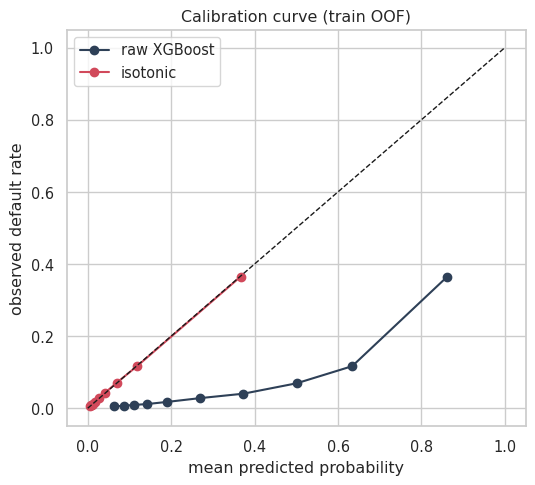

Target recall 80% -> threshold = 0.0593 (train OOF: recall=0.803, precision=0.195)


In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, precision_recall_curve
import matplotlib.pyplot as plt

TARGET_RECALL = 0.80      # business choice: share of defaulters we must catch

# cross-fitted isotonic calibration of the OOF scores
oof_cal = np.zeros_like(oof_xgb)
for a, b in StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(oof_xgb.reshape(-1, 1), y_train):
    iso = IsotonicRegression(out_of_bounds="clip").fit(oof_xgb[a], y_train.iloc[a])
    oof_cal[b] = iso.predict(oof_xgb[b])

print(f"Brier  raw={brier_score_loss(y_train, oof_xgb):.4f}   isotonic={brier_score_loss(y_train, oof_cal):.4f}")
print(f"AUC-PR raw={average_precision_score(y_train, oof_xgb):.4f}   isotonic={average_precision_score(y_train, oof_cal):.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
for lbl, p in [("raw XGBoost", oof_xgb), ("isotonic", oof_cal)]:
    frac, mean = calibration_curve(y_train, p, n_bins=10, strategy="quantile")
    ax.plot(mean, frac, marker="o", label=lbl)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="mean predicted probability", ylabel="observed default rate", title="Calibration curve (train OOF)")
ax.legend(); plt.tight_layout(); plt.show()

# threshold: highest cut-off with recall >= TARGET_RECALL
prec, rec, thr = precision_recall_curve(y_train, oof_cal)
i = np.where(rec[:-1] >= TARGET_RECALL)[0][-1]
THRESHOLD = float(thr[i])
print(f"Target recall {TARGET_RECALL:.0%} -> threshold = {THRESHOLD:.4f} "
      f"(train OOF: recall={rec[i]:.3f}, precision={prec[i]:.3f})")

## Part 10 -- Final test evaluation (run once)

Final fit:
- XGBoost on the **full training set** with the tuned params.
- Isotonic calibrator fit on the OOF scores (all training rows).

The test set gets the **train** clipping limits. No tuning or threshold change happens after this cell. `final_xgb_pipe` is the plain XGBoost pipeline, kept for SHAP.

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
import joblib

final_xgb_pipe = clone(xgb_pipe).fit(X_train, y_train)
calibrator = IsotonicRegression(out_of_bounds="clip").fit(oof_xgb, y_train)

X_test = gmsc_test[FEATURE_COLS].copy()
X_test[NUMERIC_COLS] = X_test[NUMERIC_COLS].clip(lower=lower_limits, upper=upper_limits, axis=1)  # train limits
y_test = gmsc_test[TARGET].astype(int)

p_raw  = final_xgb_pipe.predict_proba(X_test)[:, 1]
p_test = calibrator.predict(p_raw)
pred   = (p_test >= THRESHOLD).astype(int)

print("=== FINAL TEST (single evaluation) ===")
print(f"AUC-PR    : {average_precision_score(y_test, p_test):.4f}   (base rate {y_test.mean():.4f})")
print(f"ROC-AUC   : {roc_auc_score(y_test, p_test):.4f}")
print(f"Brier     : {brier_score_loss(y_test, p_test):.4f}   (raw: {brier_score_loss(y_test, p_raw):.4f})")
print(f"Threshold : {THRESHOLD:.4f}")
print(f"Recall    : {recall_score(y_test, pred):.4f}")
print(f"Precision : {precision_score(y_test, pred):.4f}")
print(f"F1        : {f1_score(y_test, pred):.4f}")
cm = confusion_matrix(y_test, pred)
display(pd.DataFrame(cm, index=["actual 0", "actual 1"], columns=["pred 0", "pred 1"]))

joblib.dump({"xgb_pipeline": final_xgb_pipe, "calibrator": calibrator, "threshold": THRESHOLD,
             "features": FEATURE_COLS, "clip_lower": lower_limits, "clip_upper": upper_limits,
             "best_params": BEST_XGB_PARAMS}, "gmsc_final_model.joblib")
print("Saved gmsc_final_model.joblib")

=== FINAL TEST (single evaluation) ===
AUC-PR    : 0.3904   (base rate 0.0668)
ROC-AUC   : 0.8647
Brier     : 0.0489   (raw: 0.1443)
Threshold : 0.0593
Recall    : 0.8185
Precision : 0.1917
F1        : 0.3107


,pred 0,pred 1
actual 0,21077,6918
actual 1,364,1641


Saved gmsc_final_model.joblib


## Part 11 -- SHAP explainability (summary + waterfall)

Uses the **final** XGBoost pipeline from Part 10 (`final_xgb_pipe`), the fitted `calibrator`, `THRESHOLD`,
and the train clipping limits. Run this cell block **after** Part 10.

Notes:
- SHAP values of XGBoost are in **log-odds of the raw model score** (before isotonic calibration).
  They tell us *which features push risk up/down and by how much*; the risk % shown to the user is the
  **calibrated** probability.
- Several features are derived from the same raw inputs (income -> log_income, obligations, surplus), so we
  also show SHAP **grouped by business driver** (additive, so grouping is exact).

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, shap

pre_fitted = final_xgb_pipe.named_steps["pre"]
xgb_model  = final_xgb_pipe.named_steps["clf"]

# readable feature names (strip the ColumnTransformer prefix "num__" / "flags__")
RAW_NAMES = [n.split("__", 1)[-1] for n in pre_fitted.get_feature_names_out()]
NICE = {
    "age": "Age",
    "derived_log_income": "Income (log)",
    "derived_obligations": "Monthly obligations",
    "derived_monthly_surplus": "Monthly surplus (income - obligations)",
    "derived_expense_ratio": "Debt ratio",
    "derived_utilization_capped": "Credit utilization",
    "dependents": "Dependents",
    "derived_late_count": "Late-payment count",
    "derived_late_severity": "Late-payment severity",
    "income_missing_flag": "Income missing",
    "dependents_missing_flag": "Dependents missing",
    "derived_placeholder_code_flag": "Placeholder (96/98) code",
    "derived_debt_ratio_outlier": "Debt ratio outlier (>5)",
    "derived_overspend_flag": "Overspend (debt ratio > 1)",
    "derived_utilization_outlier_flag": "Utilization > 1",
}
FEATURE_NAMES = [NICE.get(n, n) for n in RAW_NAMES]

# business groups (for the app / report): SHAP is additive, so summing within a group is exact
GROUPS = {
    "Late payments":      ["derived_late_count", "derived_late_severity", "derived_placeholder_code_flag"],
    "Credit utilization": ["derived_utilization_capped", "derived_utilization_outlier_flag"],
    "Income":             ["derived_log_income", "derived_obligations", "derived_monthly_surplus", "income_missing_flag"],
    "Debt ratio":         ["derived_expense_ratio", "derived_debt_ratio_outlier", "derived_overspend_flag"],
    "Age":                ["age"],
    "Dependents":         ["dependents", "dependents_missing_flag"],
}
assert sorted(sum(GROUPS.values(), [])) == sorted(RAW_NAMES), "every model feature must belong to exactly one group"


def to_matrix(X):
    """Prepared features (FEATURE_COLS, clipped) -> imputed matrix the XGBoost model actually sees."""
    return pd.DataFrame(pre_fitted.transform(X), columns=FEATURE_NAMES, index=X.index)


explainer = shap.TreeExplainer(xgb_model)


def shap_explanation(X):
    """shap.Explanation (log-odds of raw model score) for prepared features X."""
    Xm = to_matrix(X)
    return explainer(Xm)


def group_values(sv):
    """Sum SHAP values per business group -> DataFrame (rows = customers, cols = groups)."""
    vals = pd.DataFrame(sv.values, columns=RAW_NAMES)
    return pd.DataFrame({g: vals[cols].sum(axis=1) for g, cols in GROUPS.items()})

### 11.1 Summary plots (global explanation)
SHAP on a random sample of the test set (the final test evaluation in Part 10 is already done).

In [ ]:
N_SHAP = min(5000, len(X_test))
X_shap = X_test.sample(N_SHAP, random_state=RANDOM_STATE)
sv_all = shap_explanation(X_shap)

# (a) beeswarm: direction + magnitude per feature
plt.figure()
shap.plots.beeswarm(sv_all, max_display=15, show=False)
plt.title("GMSC - SHAP summary (XGBoost, log-odds of raw score)")
plt.tight_layout(); plt.savefig("gmsc_shap_summary_beeswarm.png", dpi=200, bbox_inches="tight"); plt.show()

# (b) bar: mean |SHAP| per feature
plt.figure()
shap.plots.bar(sv_all, max_display=15, show=False)
plt.title("GMSC - mean |SHAP| per feature")
plt.tight_layout(); plt.savefig("gmsc_shap_importance_bar.png", dpi=200, bbox_inches="tight"); plt.show()

# (c) bar by business group (what the app can say to the customer)
grp = group_values(sv_all)
imp = grp.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.barh(imp.index, imp.values, color="#2E4057")
ax.set(xlabel="mean |SHAP| (log-odds)", title="GMSC - importance by risk driver")
plt.tight_layout(); plt.savefig("gmsc_shap_importance_by_group.png", dpi=200, bbox_inches="tight"); plt.show()
print(imp.sort_values(ascending=False).round(4))

### 11.2 Waterfall plots (individual customers)
Three representative customers from the test set: highest-risk real defaulter, borderline (closest to the
threshold), and a lowest-risk customer.

In [ ]:
p_raw_test = final_xgb_pipe.predict_proba(X_test)[:, 1]
p_cal_test = calibrator.predict(p_raw_test)
tmp = pd.DataFrame({"p": p_cal_test, "y": y_test.values, "raw": p_raw_test}, index=X_test.index)

picks = {
    "High risk (actual default)": tmp[tmp.y == 1].sort_values(["p", "raw"], ascending=False).index[0],
    "Borderline (near threshold)": (tmp.p - THRESHOLD).abs().sort_values().index[0],
    "Low risk (actual non-default)": tmp[tmp.y == 0].sort_values(["p", "raw"]).index[0],
}

for label, idx in picks.items():
    sv_one = shap_explanation(X_test.loc[[idx]])
    plt.figure()
    shap.plots.waterfall(sv_one[0], max_display=12, show=False)
    plt.title(f"{label}  |  calibrated risk = {tmp.loc[idx, 'p']:.1%}  (threshold {THRESHOLD:.1%})", fontsize=10)
    fname = "gmsc_shap_waterfall_" + label.split(" (")[0].lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.show()

## Part 12 -- Prediction function (basis for the scenarios)

`predict_risk` takes **raw** customer data (same columns as the original CSV), optionally overrides
`MonthlyIncome`, `DebtRatio`, `NumberOfDependents`, then runs the same path as training:
feature engineering -> train clipping -> XGBoost pipeline -> isotonic calibration -> threshold.

**Important modelling choice (`keep_obligations`)**: in GMSC, `DebtRatio = monthly debt payments / income`.
If someone's income goes up 20% and `DebtRatio` stays the same, the model would silently assume their debt
payments also grew 20%. For a realistic "what if my income rises" scenario we keep the *dollar* obligations
fixed and rescale `DebtRatio` (default). If you pass `DebtRatio` yourself, your value is used as-is.

In [ ]:
import os, tempfile

RAW_COLS = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "NumberOfTime30-59DaysPastDueNotWorse", "DebtRatio",
    "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents",
]


def _features_from_raw(raw_df):
    """Raw columns -> engineered features, using the SAME code as training (build_gmsc_features)."""
    if "build_gmsc_features_df" in globals():          # preferred: if you refactored the function to take a DataFrame
        return build_gmsc_features_df(raw_df)
    with tempfile.TemporaryDirectory() as d:           # fallback: no edit to the original function needed
        p = os.path.join(d, "raw.csv")
        raw_df.to_csv(p, index=False)
        return build_gmsc_features(p)


def _prepare(raw_df):
    raw_df = raw_df.copy()
    if "SeriousDlqin2yrs" not in raw_df:                # build_gmsc_features expects the target column
        raw_df["SeriousDlqin2yrs"] = np.nan
    feats = _features_from_raw(raw_df[RAW_COLS + ["SeriousDlqin2yrs"]])
    X = feats[FEATURE_COLS].copy()
    X[NUMERIC_COLS] = X[NUMERIC_COLS].clip(lower=lower_limits, upper=upper_limits, axis=1)   # TRAIN limits
    return X


def _as_frame(customer):
    if isinstance(customer, pd.DataFrame):
        df = customer.copy()
    elif isinstance(customer, pd.Series):
        df = customer.to_frame().T
    else:
        df = pd.DataFrame([customer])
    missing = [c for c in RAW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing raw columns: {missing}")
    df = df[RAW_COLS].astype(float).reset_index(drop=True)
    return df


def predict_risk_batch(raw_df):
    """Calibrated default probability for every row of a raw DataFrame -> np.ndarray."""
    X = _prepare(_as_frame(raw_df))
    return calibrator.predict(final_xgb_pipe.predict_proba(X)[:, 1])


def predict_risk(customer, MonthlyIncome=None, DebtRatio=None, NumberOfDependents=None, keep_obligations=True):
    """
    customer : dict / Series / 1-row DataFrame with the raw GMSC columns (RAW_COLS).
    MonthlyIncome, DebtRatio, NumberOfDependents : scenario overrides (None = keep the customer's value).
    Returns dict: risk (calibrated probability), flagged (risk >= threshold), threshold, and the inputs used.
    """
    df = _as_frame(customer)
    if len(df) != 1:
        raise ValueError("predict_risk expects ONE customer; use predict_risk_batch for many.")

    old_income, old_dr = df.at[0, "MonthlyIncome"], df.at[0, "DebtRatio"]

    if MonthlyIncome is not None:
        if not MonthlyIncome > 0:
            raise ValueError("MonthlyIncome must be > 0")
        df.at[0, "MonthlyIncome"] = float(MonthlyIncome)
        if keep_obligations and DebtRatio is None and pd.notna(old_income) and old_income > 0 and pd.notna(old_dr):
            df.at[0, "DebtRatio"] = old_dr * old_income / float(MonthlyIncome)   # same $ obligations
    if DebtRatio is not None:
        if DebtRatio < 0:
            raise ValueError("DebtRatio must be >= 0")
        df.at[0, "DebtRatio"] = float(DebtRatio)
    if NumberOfDependents is not None:
        if NumberOfDependents < 0:
            raise ValueError("NumberOfDependents must be >= 0")
        df.at[0, "NumberOfDependents"] = float(NumberOfDependents)

    risk = float(predict_risk_batch(df)[0])
    return {
        "risk": risk,
        "flagged": bool(risk >= THRESHOLD),
        "threshold": float(THRESHOLD),
        "inputs_used": {c: df.at[0, c] for c in ["MonthlyIncome", "DebtRatio", "NumberOfDependents"]},
    }


def compare_scenario(customer, **changes):
    """Before vs after for the same customer, e.g. compare_scenario(c, MonthlyIncome=9000, NumberOfDependents=1)."""
    before = predict_risk(customer)
    after = predict_risk(customer, **changes)
    return {"before": before["risk"], "after": after["risk"], "delta": after["risk"] - before["risk"],
            "flag_before": before["flagged"], "flag_after": after["flagged"], "changes": changes}


def explain_customer(customer, top_k=5, plot=True, **overrides):
    """
    Why is this customer risky? Returns calibrated risk + top drivers (grouped, additive SHAP) and,
    if plot=True, the waterfall. Overrides work like predict_risk (scenario explanation).
    """
    df = _as_frame(customer)
    res = predict_risk(df, **overrides)
    # rebuild the exact row the model saw (after overrides)
    df.loc[0, ["MonthlyIncome", "DebtRatio", "NumberOfDependents"]] = [
        res["inputs_used"]["MonthlyIncome"], res["inputs_used"]["DebtRatio"], res["inputs_used"]["NumberOfDependents"]]
    X = _prepare(df)
    sv = shap_explanation(X)
    g = group_values(sv).iloc[0].sort_values(key=np.abs, ascending=False)
    drivers = [{"driver": k, "effect": ("increases risk" if v > 0 else "decreases risk"), "shap": float(v)}
               for k, v in g.head(top_k).items()]
    if plot:
        plt.figure(); shap.plots.waterfall(sv[0], max_display=12, show=False)
        plt.title(f"calibrated risk = {res['risk']:.1%}  (threshold {THRESHOLD:.1%})", fontsize=10); plt.show()
    return {**res, "drivers": drivers}

### 12.1 Quick checks + scenario demo

In [ ]:
raw_all = pd.read_csv(GMSC_PATH)                          # raw columns; row index == gmsc index
cust = raw_all.loc[picks["High risk (actual default)"], RAW_COLS]

# 1) consistency: the function on RAW data must reproduce the Part 10 test probabilities exactly
chk_idx = X_test.index[:300]
p_fn = predict_risk_batch(raw_all.loc[chk_idx, RAW_COLS])
print("max |function - Part10| =", float(np.abs(p_fn - p_cal_test[:300]).max()))   # expect ~0

# 2) scenarios
print("current risk       :", round(predict_risk(cust)["risk"], 4))
print("income +30%        :", compare_scenario(cust, MonthlyIncome=float(cust["MonthlyIncome"]) * 1.3 if pd.notna(cust["MonthlyIncome"]) else 8000))
print("debt ratio -> 0.2  :", compare_scenario(cust, DebtRatio=0.2))
print("dependents -> 0    :", compare_scenario(cust, NumberOfDependents=0))

# 3) explanation + top reasons
out = explain_customer(cust, top_k=4)
print(out["risk"], out["drivers"])